# MemVal Framework Demonstration

This notebook demonstrates the end-to-end evaluation pipeline:
1. **T-Maze Pattern Completion:** The simplest evaluation — generate a T-maze trajectory, train a Hopfield network, and test pattern completion.
2. **Spatial Sequence Pattern Completion:** A more complex random-walk trajectory.
3. **Sequence Disambiguation:** Testing catastrophic interference with crossing paths.
4. **Object Arena and Novelty Benchmarks:** Environmental object interaction tasks (NOR/OLM).

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from memval.generators.temporal import PureToneSequenceGenerator
from memval.encoders.audio import PureToneEncoder
from memval.generators.t_maze import TMazeGenerator
from memval.generators.spatial import SpatialSequenceGenerator
from memval.generators.object_arena import ObjectArenaGenerator
from memval.models.baselines import HopfieldSequenceNetwork
from memval.benchmarks import PatternCompletionBenchmark
from memval.benchmarks.novelty import NoveltyBenchmark
from memval.encoders.spatial import PlaceCellEncoder

sns.set_theme(style='darkgrid')

## 1. T-Maze Pattern Completion (Simplest Example)
The T-maze is a classic hippocampal benchmark: the agent walks up a central stem then turns left or right. We generate a single trajectory, train a Hopfield Sequence Network on it, and test pattern completion by providing only the first 30% as a cue.

T-Maze Pattern Completion Results: {'pattern_completion_mse': 0.1378981751430731}


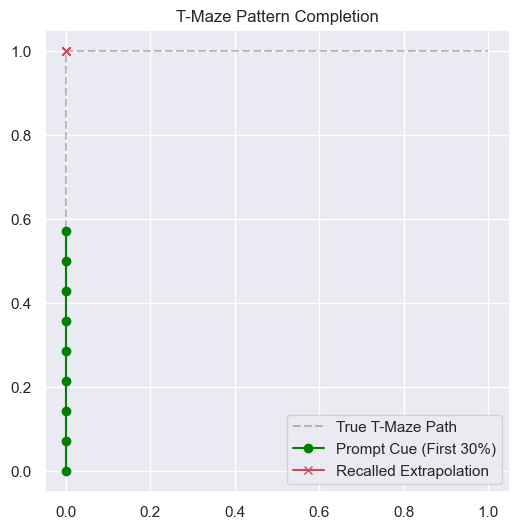

In [5]:
# --- Generate a T-Maze trajectory ---
n_seqs = 1
seq_len = 30
tmaze_gen = TMazeGenerator(seed=42)
tmaze_trajectories = tmaze_gen.generate(
    n_sequences=n_seqs, sequence_length=seq_len, turn_direction='right'
)
tmaze_seq = tmaze_trajectories[0]

# --- Train a Hopfield network and evaluate pattern completion ---
model_tmaze = HopfieldSequenceNetwork(
    n_features=2, learning_rate=0.5, activation='sign'
)
model_tmaze.fit_sequence(tmaze_seq)

benchmark_pc = PatternCompletionBenchmark(metric='mse')
pc_results = benchmark_pc.evaluate(
    model_tmaze, tmaze_trajectories, prompt_fraction=0.3
)
print('T-Maze Pattern Completion Results:', pc_results)

# --- Visualize ---
prompt_len = int(seq_len * 0.3)
prompt = tmaze_seq[:prompt_len]
model_tmaze.reset_context()
reconstructed = model_tmaze.recall(prompt, length=seq_len - prompt_len)

plt.figure(figsize=(6, 6))
plt.plot(
    tmaze_seq[:, 0], tmaze_seq[:, 1],
    '--', color='gray', alpha=0.5, label='True T-Maze Path'
)
plt.plot(
    prompt[:, 0], prompt[:, 1],
    '-o', color='green', label='Prompt Cue (First 30%)'
)
plt.plot(
    reconstructed[:, 0], reconstructed[:, 1],
    '-rx', label='Recalled Extrapolation'
)
plt.title('T-Maze Pattern Completion')
plt.legend()
plt.show()

### 1.1. Improved T-Maze with Place Cell Encoding
Similar to the random walk, we can apply the Place Cell Encoder to the T-maze. This helps the Hopfield network better represent the sharp turn at the T-junction, which is a highly non-linear transition in raw 2D space.

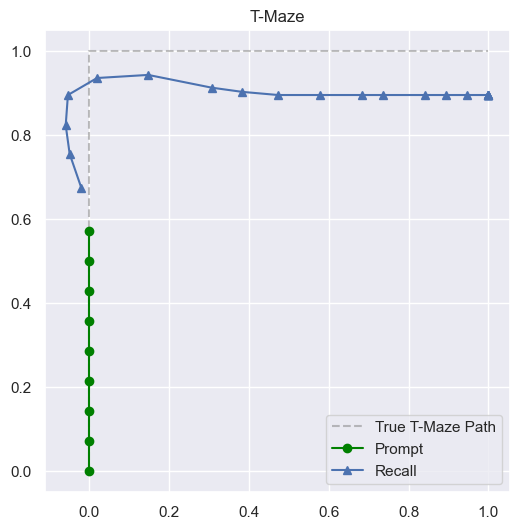

In [ ]:
# --- 1. Encode T-Maze Trajectory ---
encoder = PlaceCellEncoder(seed=42)
tmaze_seq_encoded = encoder.encode(tmaze_seq)

# --- 2. Train Hopfield with Delta Rule (Sequential Learning) ---
model_tmaze_pc = HopfieldSequenceNetwork(
    n_features=encoder.n_cells, learning_rate=0.1, 
    activation='relu', fit_method='delta'
)
model_tmaze_pc.fit_sequence(tmaze_seq_encoded, epochs=100)

# --- 3. Evaluate and Recall ---
prompt_tmaze_pc = tmaze_seq_encoded[:prompt_len]
model_tmaze_pc.reset_context()
recon_tmaze_encoded = model_tmaze_pc.recall(prompt_tmaze_pc, length=seq_len - prompt_len)

# --- 4. Decode back to 2D ---
reconstructed_tmaze_pc = encoder.decode(recon_tmaze_encoded)

# --- 5. Visualize Results ---
plt.figure(figsize=(6, 6))
plt.plot(tmaze_seq[:, 0], tmaze_seq[:, 1], '--', color='gray', alpha=0.5, label='True T-Maze Path')
plt.plot(prompt[:, 0], prompt[:, 1], '-o', color='green', label='Prompt')
# plt.plot(reconstructed[:, 0], reconstructed[:, 1], '-rx', alpha=0.4, label='Vanilla Hopfield')
plt.plot(reconstructed_tmaze_pc[:, 0], reconstructed_tmaze_pc[:, 1], '-b^', label='Recall')
plt.title('T-Maze')
plt.legend()
plt.show()

## 2. Spatial Sequence Pattern Completion
A more complex example: we generate a 2D random-walk trajectory with momentum and test the Hopfield network's ability to recall spatial sequences from a partial cue.

Spatial Sequence Pattern Completion Results: {'pattern_completion_mse': 0.002681584422103374}


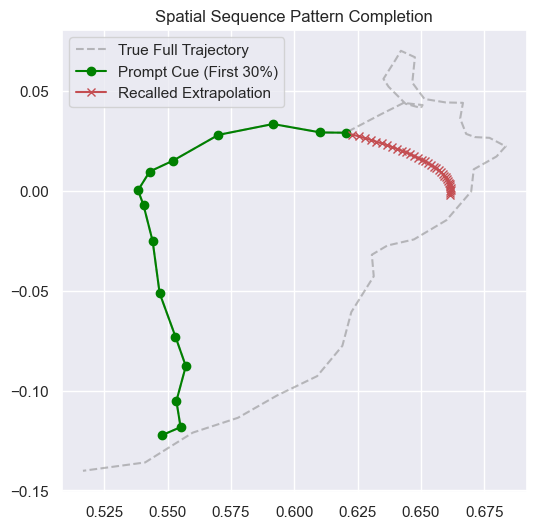

In [8]:
n_seqs = 1
seq_len = 50
gen = SpatialSequenceGenerator(n_dimensions=2, seed=42)
trajectories = gen.generate(
    n_sequences=n_seqs, sequence_length=seq_len,
    step_size=0.1, momentum=0.9
)

true_seq = trajectories[0]

model = HopfieldSequenceNetwork(
    n_features=2, learning_rate=0.5, activation='linear'
)
model.fit_sequence(true_seq)

benchmark_pc2 = PatternCompletionBenchmark(metric='mse')
pc_results2 = benchmark_pc2.evaluate(
    model, trajectories, prompt_fraction=0.3
)
print('Spatial Sequence Pattern Completion Results:', pc_results2)

# Visualize
prompt_len = int(seq_len * 0.3)
prompt = true_seq[:prompt_len]
model.reset_context()
reconstructed = model.recall(prompt, length=seq_len - prompt_len)

plt.figure(figsize=(6, 6))
plt.plot(
    true_seq[:, 0], true_seq[:, 1],
    '--', color='gray', alpha=0.5, label='True Full Trajectory'
)
plt.plot(
    prompt[:, 0], prompt[:, 1],
    '-o', color='green', label='Prompt Cue (First 30%)'
)
plt.plot(
    reconstructed[:, 0], reconstructed[:, 1],
    '-rx', label='Recalled Extrapolation'
)
plt.title('Spatial Sequence Pattern Completion')
plt.legend()
plt.show()

### 2.1. Improved Spatial Sequence with Place Cell Encoding
Now we demonstrate the "Biological Sensory Gateway". By projecting the 2D coordinates into a high-dimensional sparse Place Cell activation grid (e.g., 400 cells), we allow the shallow Hopfield network to capture non-linear paths without corner-cutting or decay.

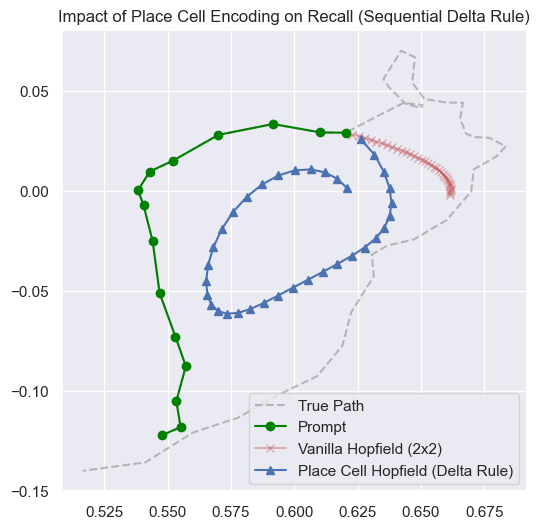

In [9]:
from memval.encoders import PlaceCellEncoder

# --- 1. Encode Trajectory ---
encoder = PlaceCellEncoder(n_cells_per_dim=20, sigma=0.1, env_bounds=1.0, seed=42)
true_seq_encoded = encoder.encode(true_seq)

# --- 2. Train Hopfield with Delta Rule ---
model_pc = HopfieldSequenceNetwork(
    n_features=encoder.n_cells, learning_rate=0.1, 
    activation='relu', fit_method='delta'
)
model_pc.fit_sequence(true_seq_encoded, epochs=100)

# --- 3. Evaluate and Recall ---
prompt_pc = true_seq_encoded[:prompt_len]
model_pc.reset_context()
recon_encoded = model_pc.recall(prompt_pc, length=seq_len - prompt_len)

# --- 4. Decode back to 2D ---
reconstructed_pc = encoder.decode(recon_encoded)

# --- 5. Visualize Results ---
plt.figure(figsize=(6, 6))
plt.plot(true_seq[:, 0], true_seq[:, 1], '--', color='gray', alpha=0.5, label='True Path')
plt.plot(prompt[:, 0], prompt[:, 1], '-o', color='green', label='Prompt')
plt.plot(reconstructed[:, 0], reconstructed[:, 1], '-rx', alpha=0.4, label='Vanilla Hopfield (2x2)')
plt.plot(reconstructed_pc[:, 0], reconstructed_pc[:, 1], '-b^', label='Place Cell Hopfield (Delta Rule)')
plt.title('Impact of Place Cell Encoding on Recall (Sequential Delta Rule)')
plt.legend()
plt.show()

## 3. Sequence Disambiguation Benchmark
What happens when the model learns crossing paths? Let's engineer overlapping spatial sequences to test disambiguation.

Disambiguation Results: {'disambiguation_error_seq1_mse': 0.3563218390804597, 'disambiguation_error_seq2_mse': 0.3904920026373048, 'disambiguation_error_mean_mse': 0.3734069208588823}


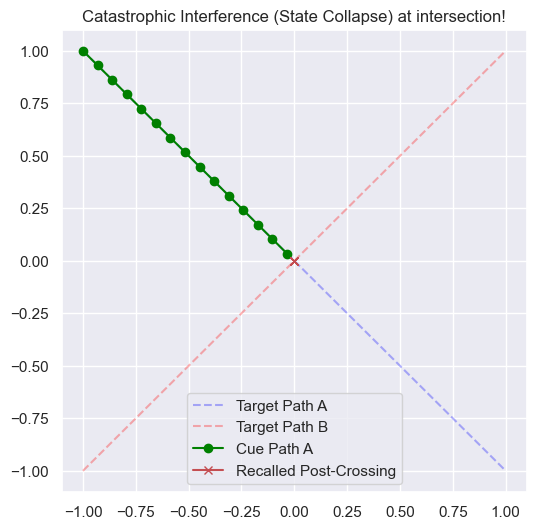

In [4]:
# Trajectory A: Top-Left to Bottom-Right passing through (0,0)
seq_A_x = np.linspace(-1, 1, 30)
seq_A_y = np.linspace(1, -1, 30)
seq_A = np.column_stack([seq_A_x, seq_A_y])

# Trajectory B: Bottom-Left to Top-Right passing through (0,0)
seq_B_x = np.linspace(-1, 1, 30)
seq_B_y = np.linspace(-1, 1, 30)
seq_B = np.column_stack([seq_B_x, seq_B_y])

# They perfectly intersect at the middle index 14-16 (passing the origin)
# The single Hopfield associative layer WILL catastrophically interfere at the crossing.

model.reset_context()
model.W *= 0.0 # reset weights

# DisambiguationBenchmark was removed 2026-09-03: it was never wired into
# a pipeline and the shipped disambiguation section is
# benchmarks/spatial_disambiguation.py. Fit both crossing routes directly
# and score the post-crossing suffix inline.
model.fit_sequence(seq_A)
model.fit_sequence(seq_B)

def suffix_mse(m, seq, ol_start=15):
    m.reset_context()
    rec = m.recall(seq[:ol_start], length=len(seq) - ol_start)
    return float(np.mean((np.asarray(rec) - seq[ol_start:]) ** 2))

print('Suffix MSE through the crossing  A:', suffix_mse(model, seq_A),
      ' B:', suffix_mse(model, seq_B))

# Why did it fail wildly? Let's cue it down Seq A visually.
prompt_A = seq_A[:15]
model.reset_context()
recall_A_cross = model.recall(prompt_A, length=15)

plt.figure(figsize=(6,6))
plt.plot(seq_A[:, 0], seq_A[:, 1], '--', color='blue', alpha=0.3, label='Target Path A')
plt.plot(seq_B[:, 0], seq_B[:, 1], '--', color='red', alpha=0.3, label='Target Path B')
plt.plot(prompt_A[:, 0], prompt_A[:, 1], '-o', color='green', label='Cue Path A')
plt.plot(recall_A_cross[:, 0], recall_A_cross[:, 1], '-rx', label='Recalled Post-Crossing')
plt.title('Catastrophic Interference (State Collapse) at intersection!')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

## 4. Object Arena and Novelty Benchmarks
We expand the evaluation framework beyond spatial navigation to test object-based assays like Novel Object Recognition (NOR) and Object Location Memory (OLM).

In [5]:
from memval.generators.object_arena import ObjectArenaGenerator
from memval.benchmarks.novelty import NoveltyBenchmark

# 1. Instantiating the Generator
gen = ObjectArenaGenerator(n_objects=3, n_locations=3, seed=42)
# Familiar sequence with mapping [0, 1, 2] corresponding to locations 0, 1, 2
familiar_seqs = gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 1, 2], interaction_radius=0.15)

# 2. OLM (Displacement) - Object 2 is moved to Location 1 instead of Location 2
test_seqs_olm = gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 2, 2], interaction_radius=0.15)

# 3. Control (Same mapping as familiar)
test_seqs_control = gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 1, 2], interaction_radius=0.15)

# Note: Features = 2D spatial + 3D object one-hot = 5 dimensions
model = HopfieldSequenceNetwork(n_features=5, learning_rate=0.5, activation="linear")

benchmark = NoveltyBenchmark(metric="mse")
res_olm = benchmark.evaluate(model, familiar_seqs, test_seqs_olm)
res_control = benchmark.evaluate(model, familiar_seqs, test_seqs_control)

print("Control (Familiar) Novelty Error Spike:", res_control)
print("OLM (Displacement) Novelty Error Spike:", res_olm)


Control (Familiar) Novelty Error Spike: {'novelty_score_mse': 0.08686468984927526}
OLM (Displacement) Novelty Error Spike: {'novelty_score_mse': 0.08336125074214701}


## 5. Pure Tone Sequence Pattern Completion (Audio Modality)
We now demonstrate abstract sequence learning on a completely different modality: audio pure tones. 
The generator creates an ascending scale of frequencies (arpeggio), and the `PureToneEncoder` maps these continuous frequencies into a discrete latent space (frequency bins). The exact same `HopfieldSequenceNetwork` is used!

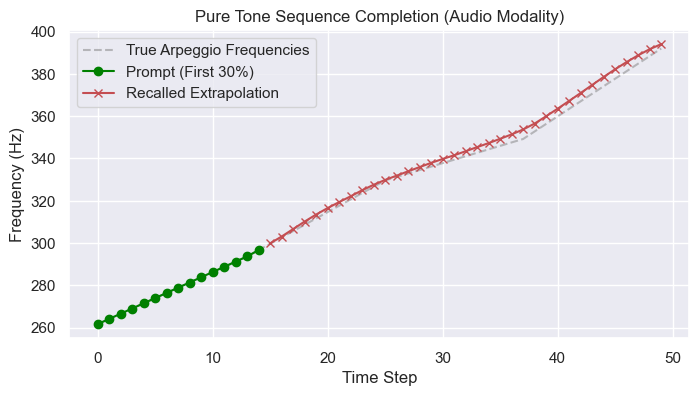

In [11]:
# --- 1. Generate Pure Tone Sequence ---
n_seqs = 1
seq_len = 50
tone_gen = PureToneSequenceGenerator(base_frequencies=[261.63, 293.66, 329.63, 349.23, 392.00], seed=42)
tone_trajectories = tone_gen.generate(n_sequences=n_seqs, sequence_length=seq_len)
tone_seq = tone_trajectories[0]

# --- 2. Encode to 'Frequency Bins' Latent Space ---
audio_encoder = PureToneEncoder(n_bins=50, min_freq=200, max_freq=600, sigma=15, seed=42)
tone_seq_encoded = audio_encoder.encode(tone_seq)

# --- 3. Train Hopfield Network (Black Box) ---
model_audio = HopfieldSequenceNetwork(
    n_features=audio_encoder.n_cells, learning_rate=0.1, 
    activation='relu', fit_method='delta'
)
model_audio.fit_sequence(tone_seq_encoded, epochs=100)

# --- 4. Evaluate Pattern Completion ---
prompt_len = int(seq_len * 0.3)
prompt_audio_encoded = tone_seq_encoded[:prompt_len]
model_audio.reset_context()
recon_audio_encoded = model_audio.recall(prompt_audio_encoded, length=seq_len - prompt_len)

# --- 5. Decode back to Frequencies ---
reconstructed_audio = audio_encoder.decode(recon_audio_encoded)

# --- 6. Visualize ---
time_steps = np.arange(seq_len)
plt.figure(figsize=(8, 4))
plt.plot(time_steps, tone_seq[:, 0], '--', color='gray', alpha=0.5, label='True Arpeggio Frequencies')
plt.plot(time_steps[:prompt_len], tone_seq[:prompt_len, 0], '-o', color='green', label='Prompt (First 30%)')

# The recalled output starts after the prompt
time_recalled = np.arange(prompt_len, seq_len)
plt.plot(time_recalled, reconstructed_audio[:, 0], '-rx', label='Recalled Extrapolation')

plt.title('Pure Tone Sequence Completion (Audio Modality)')
plt.xlabel('Time Step')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.show()


In [5]:
from IPython.display import Audio

def synthesize_trajectory(freq_traj, sample_rate=44100, step_duration=0.04):
    """Synthesizes a continuous waveform from a frequency trajectory."""
    # freq_traj is (seq_len, 1)
    import numpy as np
    seq_len = freq_traj.shape[0]
    t_steps = np.arange(seq_len) * step_duration
    t_total = seq_len * step_duration
    t_audio = np.linspace(0, t_total, int(sample_rate * t_total), endpoint=False)
    
    # Interpolate frequencies to create smooth transitions
    freq_interp = np.interp(t_audio, t_steps, freq_traj[:, 0])
    
    # Instantaneous phase is the integral of frequency
    dt = 1.0 / sample_rate
    phase = 2 * np.pi * np.cumsum(freq_interp * dt)
    waveform = 0.5 * np.sin(phase)
    return waveform

# Synthesize Original and Reconstructed
sample_rate = 22050 # Lower SR is fine for beeps
orig_wave = synthesize_trajectory(tone_seq, sample_rate=sample_rate)
recon_wave = synthesize_trajectory(reconstructed_audio, sample_rate=sample_rate)

print("Original Scale (Training Path):")
display(Audio(orig_wave, rate=sample_rate))

print("Reconstructed/Recalled Scale (Predicted Extrapolation):")
display(Audio(recon_wave, rate=sample_rate))


Original Scale (Training Path):


Reconstructed/Recalled Scale (Predicted Extrapolation):
